In [1]:
import sklearn
print(sklearn.__version__)

1.7.2


In [2]:
# First, we import our libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.svm import SVC

## TITANIC DATA SET

In [3]:
titanic = pd.read_csv('data/titanic.csv')
titanic


,Survived,Pclass,Name,Sex,Age,SibSp,PaCh,Fare
0,0,3,Mr. Owen Harris Braund,male,22.0,1,0,7.2500
1,1,1,Mrs. John Bradley (Florence Briggs Thayer) Cum...,female,38.0,1,0,71.2833
2,1,3,Miss. Laina Heikkinen,female,26.0,0,0,7.9250
3,1,1,Mrs. Jacques Heath (Lily May Peel) Futrelle,female,35.0,1,0,53.1000
4,0,3,Mr. William Henry Allen,male,35.0,0,0,8.0500
...,...,...,...,...,...,...,...,...
882,0,2,Rev. Juozas Montvila,male,27.0,0,0,13.0000
883,1,1,Miss. Margaret Edith Graham,female,19.0,0,0,30.0000
884,0,3,Miss. Catherine Helen Johnston,female,7.0,1,2,23.4500
885,1,1,Mr. Karl Howell Behr,male,26.0,0,0,30.0000


In [4]:
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 887 entries, 0 to 886
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  887 non-null    int64  
 1   Pclass    887 non-null    int64  
 2   Name      887 non-null    object 
 3   Sex       887 non-null    object 
 4   Age       887 non-null    float64
 5   SibSp     887 non-null    int64  
 6   PaCh      887 non-null    int64  
 7   Fare      887 non-null    float64
dtypes: float64(2), int64(4), object(2)
memory usage: 55.6+ KB


In [5]:
titanic.isnull().sum()

Survived    0
Pclass      0
Name        0
Sex         0
Age         0
SibSp       0
PaCh        0
Fare        0
dtype: int64

In [7]:
titanic["Survived"].value_counts()

Survived
0    545
1    342
Name: count, dtype: int64

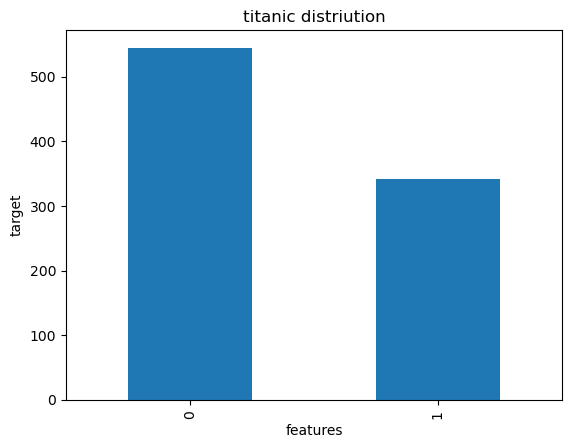

In [8]:
titanic["Survived"].value_counts().plot(kind = "bar")
plt.title("titanic distriution")
plt.xlabel("features")
plt.ylabel("target")
plt.show()

In [9]:
titanic.describe()

,Survived,Pclass,Age,SibSp,PaCh,Fare
count,887.000000,887.000000,887.000000,887.000000,887.000000,887.00000
mean,0.385569,2.305524,29.471443,0.525366,0.383315,32.30542
std,0.487004,0.836662,14.121908,1.104669,0.807466,49.78204
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.00000
25%,0.000000,2.000000,20.250000,0.000000,0.000000,7.92500
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.45420
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.13750
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.32920


In [11]:
features= ['Pclass', 'Sex', 'Age', 'SibSp', 'PaCh', 'Fare']

target = 'Survived'
X=titanic[features].copy()
y= titanic["Survived"].copy()

In [12]:
X.head()

,Pclass,Sex,Age,SibSp,PaCh,Fare
0,3,male,22.0,1,0,7.2500
1,1,female,38.0,1,0,71.2833
2,3,female,26.0,0,0,7.9250
3,1,female,35.0,1,0,53.1000
4,3,male,35.0,0,0,8.0500


In [13]:
y.head()

0    0
1    1
2    1
3    1
4    0
Name: Survived, dtype: int64

In [14]:
X["Sex"]=X["Sex"].apply(lambda x: 1 if x == "female" else 0)

In [15]:
X.head()

,Pclass,Sex,Age,SibSp,PaCh,Fare
0,3,0,22.0,1,0,7.2500
1,1,1,38.0,1,0,71.2833
2,3,1,26.0,0,0,7.9250
3,1,1,35.0,1,0,53.1000
4,3,0,35.0,0,0,8.0500


In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state= 42, stratify = y)


In [18]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (709, 6)
X_test: (178, 6)


In [19]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [20]:
logistic_model = LogisticRegression(max_iter = 1000)
logistic_model.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [22]:
model_prediction = logistic_model.predict(X_test_scaled)

model_accuracy= accuracy_score(
    y_test,
    model_prediction
)
print("Logistic Regression:", model_accuracy)

Logistic Regression: 0.7696629213483146


In [23]:
print(classification_report(y_test, model_prediction))

              precision    recall  f1-score   support

           0       0.80      0.83      0.81       109
           1       0.71      0.68      0.70        69

    accuracy                           0.77       178
   macro avg       0.76      0.75      0.76       178
weighted avg       0.77      0.77      0.77       178



In [24]:
tree_model = DecisionTreeClassifier(max_depth=3, random_state = 42)
tree_model.fit(X_train_scaled, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [25]:
tree_prediction = tree_model.predict(X_test_scaled)
tree_accuracy = accuracy_score(
    y_test,
    tree_prediction
)
print("Decision Tree:", tree_accuracy)

Decision Tree: 0.8033707865168539


In [26]:
print(classification_report(y_test, tree_prediction))

              precision    recall  f1-score   support

           0       0.81      0.89      0.85       109
           1       0.79      0.67      0.72        69

    accuracy                           0.80       178
   macro avg       0.80      0.78      0.79       178
weighted avg       0.80      0.80      0.80       178



In [28]:
random_model = RandomForestClassifier(max_depth = 5, random_state = 42, n_estimators = 150)
random_model.fit(X_train_scaled, y_train)

,n_estimators,150
,criterion,'gini'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [30]:
random_prediction = random_model.predict(X_test_scaled)
random_accuracy = accuracy_score(
    y_test,
    random_prediction
)
print("RandomForestClassifier:", random_accuracy)

RandomForestClassifier: 0.7921348314606742


In [31]:
print(classification_report(y_test, random_prediction))

              precision    recall  f1-score   support

           0       0.79      0.91      0.84       109
           1       0.81      0.61      0.69        69

    accuracy                           0.79       178
   macro avg       0.80      0.76      0.77       178
weighted avg       0.79      0.79      0.79       178



In [34]:
result = pd.DataFrame({
    "Model":[
    "logistic_model",
    "tree_model",
    "forest_model"
    ],
    "accuracy": [
        model_accuracy,
        tree_accuracy,
        random_accuracy
    ]
})
result

,Model,accuracy
0,logistic_model,0.769663
1,tree_model,0.803371
2,forest_model,0.792135


In [36]:
result.sort_values(by = "accuracy", ascending = False)

,Model,accuracy
1,tree_model,0.803371
2,forest_model,0.792135
0,logistic_model,0.769663


In [39]:
work = pd.DataFrame([
    ['F', 24, 'Ilorin', 'Y', 'Basic', 72, 78, 'Yes', 75, 'Yes'],
    ['M', 29, 'Lagos', 'Y', 'Intermediate', 81, 70, 'Yes', 82, 'Yes'],
    ['F', 21, 'Ilorin', 'Y', 'None', 65, 74, 'No', 68, 'Yes'],
    ['M', 32, 'Abuja', 'Y', 'Advanced', 88, 85, 'Yes', 91, 'Yes'],
    ['F', 19, 'Ibadan', 'N', 'Basic', 54, 62, 'No', 58, 'No'],
    ['F', 27, 'Ilorin', 'Y', 'Intermediate', 79, 83, 'Yes', 80, 'Yes'],
    ['M', 23, 'Kano', 'Y', 'Basic', 61, 65, 'No', 63, 'No'],
    ['F', 30, 'Lagos', 'Y', 'Advanced', 91, 88, 'Yes', 94, 'Yes'],
    ['M', 20, 'Ilorin', 'N', 'None', 48, 55, 'No', 51, 'No'],
    ['F', 26, 'Abuja', 'Y', 'Intermediate', 76, 79, 'Yes', 77, 'Yes'],
    ['M', 34, 'Lagos', 'Y', 'Basic', 68, 64, 'Yes', 70, 'No'],
    ['F', 22, 'Ilorin', 'Y', 'Basic', 70, 72, 'No', 74, 'Yes'],
    ['F', 28, 'Ibadan', 'Y', 'Advanced', 89, 91, 'Yes', 88, 'Yes'],
    ['M', 25, 'Port Harcourt', 'Y', 'Intermediate', 73, 69, 'Yes', 76, 'Yes'],
    ['F', 18, 'Kano', 'N', 'None', 45, 52, 'No', 49, 'No'],
    ['M', 31, 'Abuja', 'Y', 'Advanced', 85, 80, 'Yes', 87, 'Yes'],
    ['F', 23, 'Ilorin', 'Y', 'Basic', 67, 75, 'No', 71, 'Yes'],
    ['M', 27, 'Lagos', 'N', 'Basic', 59, 61, 'No', 64, 'No'],
    ['F', 29, 'Ilorin', 'Y', 'Intermediate', 82, 86, 'Yes', 84, 'Yes'],
    ['M', 21, 'Ibadan', 'N', 'None', 52, 58, 'No', 55, 'No']
], columns=[
    'Gender',
    'Age',
    'City',
    'Graduated',
    'Python_Knowledge',
    'Math_Score',
    'Interview_Score',
    'Previous_Experience',
    'Coding_Test_Score',
    'Accepted'
])

work

,Gender,Age,City,Graduated,Python_Knowledge,Math_Score,Interview_Score,Previous_Experience,Coding_Test_Score,Accepted
0,F,24,Ilorin,Y,Basic,72,78,Yes,75,Yes
1,M,29,Lagos,Y,Intermediate,81,70,Yes,82,Yes
2,F,21,Ilorin,Y,None,65,74,No,68,Yes
3,M,32,Abuja,Y,Advanced,88,85,Yes,91,Yes
4,F,19,Ibadan,N,Basic,54,62,No,58,No
5,F,27,Ilorin,Y,Intermediate,79,83,Yes,80,Yes
6,M,23,Kano,Y,Basic,61,65,No,63,No
7,F,30,Lagos,Y,Advanced,91,88,Yes,94,Yes
8,M,20,Ilorin,N,None,48,55,No,51,No
9,F,26,Abuja,Y,Intermediate,76,79,Yes,77,Yes


In [40]:
work.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Gender               20 non-null     object
 1   Age                  20 non-null     int64 
 2   City                 20 non-null     object
 3   Graduated            20 non-null     object
 4   Python_Knowledge     20 non-null     object
 5   Math_Score           20 non-null     int64 
 6   Interview_Score      20 non-null     int64 
 7   Previous_Experience  20 non-null     object
 8   Coding_Test_Score    20 non-null     int64 
 9   Accepted             20 non-null     object
dtypes: int64(4), object(6)
memory usage: 1.7+ KB


In [41]:
work.isnull().sum()

Gender                 0
Age                    0
City                   0
Graduated              0
Python_Knowledge       0
Math_Score             0
Interview_Score        0
Previous_Experience    0
Coding_Test_Score      0
Accepted               0
dtype: int64

In [42]:
work.describe()

,Age,Math_Score,Interview_Score,Coding_Test_Score
count,20.000000,20.000000,20.000000,20.000000
mean,25.450000,70.250000,72.350000,72.850000
std,4.570788,13.905224,11.458277,13.168043
min,18.000000,45.000000,52.000000,49.000000
25%,21.750000,60.500000,63.500000,63.750000
50%,25.500000,71.000000,73.000000,74.500000
75%,29.000000,81.250000,80.750000,82.500000
max,34.000000,91.000000,91.000000,94.000000


In [43]:
work.columns

Index(['Gender', 'Age', 'City', 'Graduated', 'Python_Knowledge', 'Math_Score',
       'Interview_Score', 'Previous_Experience', 'Coding_Test_Score',
       'Accepted'],
      dtype='object')

In [45]:
features = ['Gender', 'Age', 'City', 'Graduated', 'Python_Knowledge', 'Math_Score',
       'Interview_Score', 'Previous_Experience', 'Coding_Test_Score']
target = 'Accepted'
X =work[features].copy()
y = work["Accepted"].copy()

In [46]:
X['Gender'] = X['Gender'].map({'F': 0, 'M': 1})

X['Graduated'] = X['Graduated'].map({'N': 0, 'Y': 1})

X['Previous_Experience'] = X['Previous_Experience'].map({'No': 0, 'Yes': 1})

In [47]:
X.head()

,Gender,Age,City,Graduated,Python_Knowledge,Math_Score,Interview_Score,Previous_Experience,Coding_Test_Score
0,0,24,Ilorin,1,Basic,72,78,1,75
1,1,29,Lagos,1,Intermediate,81,70,1,82
2,0,21,Ilorin,1,None,65,74,0,68
3,1,32,Abuja,1,Advanced,88,85,1,91
4,0,19,Ibadan,0,Basic,54,62,0,58


In [48]:
X['Python_Knowledge'] = X['Python_Knowledge'].map({
    'None': 0,
    'Basic': 1,
    'Intermediate': 2,
    'Advanced': 3
})

In [49]:
X.head()

,Gender,Age,City,Graduated,Python_Knowledge,Math_Score,Interview_Score,Previous_Experience,Coding_Test_Score
0,0,24,Ilorin,1,1,72,78,1,75
1,1,29,Lagos,1,2,81,70,1,82
2,0,21,Ilorin,1,0,65,74,0,68
3,1,32,Abuja,1,3,88,85,1,91
4,0,19,Ibadan,0,1,54,62,0,58


In [50]:
X = pd.get_dummies(X, columns=['City'], dtype=int)

In [51]:
X.head()

,Gender,Age,Graduated,Python_Knowledge,Math_Score,Interview_Score,Previous_Experience,Coding_Test_Score,City_Abuja,City_Ibadan,City_Ilorin,City_Kano,City_Lagos,City_Port Harcourt
0,0,24,1,1,72,78,1,75,0,0,1,0,0,0
1,1,29,1,2,81,70,1,82,0,0,0,0,1,0
2,0,21,1,0,65,74,0,68,0,0,1,0,0,0
3,1,32,1,3,88,85,1,91,1,0,0,0,0,0
4,0,19,0,1,54,62,0,58,0,1,0,0,0,0


In [52]:
X.dtypes

Gender                 int64
Age                    int64
Graduated              int64
Python_Knowledge       int64
Math_Score             int64
Interview_Score        int64
Previous_Experience    int64
Coding_Test_Score      int64
City_Abuja             int64
City_Ibadan            int64
City_Ilorin            int64
City_Kano              int64
City_Lagos             int64
City_Port Harcourt     int64
dtype: object

In [53]:
y = y.map({"Yes" : 1, "No": 0})

In [54]:
y.head()

0    1
1    1
2    1
3    1
4    0
Name: Accepted, dtype: int64

In [57]:
X_train, X_test, y_train,y_test = train_test_split(X, y, test_size= 0.2, random_state= 42, stratify = y)

In [58]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (16, 14)
X_test: (4, 14)


## USING LOGISTIC_MODEL

In [69]:
scaler = StandardScaler()
X_train_scaled= scaler. fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [70]:
logistic_model = LogisticRegression(max_iter=1000)
logistic_model.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [73]:
logistic_prediction = logistic_model.predict(X_test_scaled)
logistic_accuracy = accuracy_score(
    y_test,
    logistic_prediction
)
print("Logistic Regression:", logistic_accuracy)

Logistic Regression: 1.0


In [74]:
print(classification_report(y_test, logistic_prediction))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         3

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4



## DECISION TREE

In [75]:
tree_model = DecisionTreeClassifier(random_state = 42, max_depth = 3)
tree_model.fit(X_train_scaled, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [81]:
tree_prediction = tree_model.predict(X_test_scaled)

tree_accuracy = accuracy_score(
    y_test,
    tree_prediction
)
print("Decision Tree:", tree_accuracy *100,"%")

Decision Tree: 100.0 %


In [78]:
print(classification_report(y_test, tree_prediction))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         3

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4



In [85]:
random_model = RandomForestClassifier(max_depth = 5, random_state= 42, n_estimators = 150)
random_model.fit(X_train_scaled, y_train)

,n_estimators,150
,criterion,'gini'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [86]:
random_prediction = random_model.predict(X_test_scaled)

random_accuracy = accuracy_score(
    y_test,
    random_prediction
)
print("Random Forest Classifier:",random_accuracy)

Random Forest Classifier: 1.0


In [87]:
print(classification_report(y_test, random_prediction))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         3

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4



In [89]:
results = pd.DataFrame({
    "Model":[
    "logistic_model",
    "tree_model",
    "forest_model"
    ],
    "accuracy": [
        logistic_accuracy * 100,
        tree_accuracy * 100,
        random_accuracy * 100
    ]
})
results

,Model,accuracy
0,logistic_model,100.0
1,tree_model,100.0
2,forest_model,100.0


## ASSIGNMENT

In [3]:
fellow = pd.read_csv("data/fellowship_data.csv")
fellow

,Name,Gender,Age,City,Graduate,Accepted
0,Kemi Bello,Female,25,Ilorin,Yes,Yes
1,Ngozi Afolabi,Female,31,Ilorin,Yes,Yes
2,Peace Afolabi,Female,30,Kano,Yes,No
3,Ngozi Afolabi,Female,35,Ilorin,Yes,Yes
4,Mariam Bello,Female,20,Ilorin,Yes,Yes
...,...,...,...,...,...,...
95,Funmi Jesu,Female,31,Ilorin,Yes,Yes
96,Bimpe Lawal,Female,21,Ilorin,Yes,Yes
97,Bayo Yusuf,Male,33,Enugu,Yes,No
98,Kunle Okafor,Male,24,Ibadan,Yes,No


In [4]:
fellow.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Name      100 non-null    object
 1   Gender    100 non-null    object
 2   Age       100 non-null    int64 
 3   City      100 non-null    object
 4   Graduate  100 non-null    object
 5   Accepted  100 non-null    object
dtypes: int64(1), object(5)
memory usage: 4.8+ KB


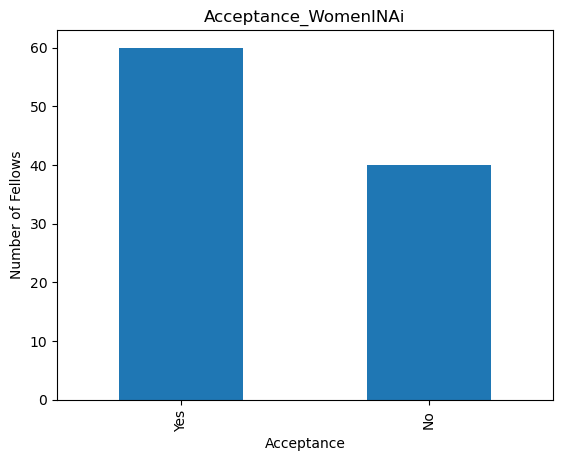

In [5]:
fellow["Accepted"].value_counts().plot(kind="bar")
plt.title("Acceptance_WomenINAi")
plt.xlabel("Acceptance")
plt.ylabel("Number of Fellows")
plt.show()

In [93]:
fellow.isnull().sum()

Name        0
Gender      0
Age         0
City        0
Graduate    0
Accepted    0
dtype: int64

In [31]:
fellow["City"].unique()

array(['Ilorin', 'Kano', 'Ibadan', 'Port Harcourt', 'Enugu', 'Abuja',
       'Kaduna', 'Lagos', 'Sokoto', 'Benin City', 'Osogbo'], dtype=object)

In [94]:
fellow.describe()

,Age
count,100.000000
mean,28.030000
std,7.038789
min,16.000000
25%,22.000000
50%,27.500000
75%,33.000000
max,45.000000


In [6]:
fellow.columns

Index(['Name', 'Gender', 'Age', 'City', 'Graduate', 'Accepted'], dtype='object')

In [7]:
fellow_ilorin = fellow[fellow['City'] == 'Ilorin'].copy()

In [8]:
fellow_ilorin = fellow_ilorin[
    (fellow_ilorin["Gender"] == "Female") &
    (fellow_ilorin["Age"].between(18, 35))
]

In [9]:
X = fellow_ilorin[["Age", "Graduate"]]

y = fellow_ilorin["Accepted"]

In [10]:
X["Graduate"] = X["Graduate"].map({"No": 0, "Yes": 1})

y = y.map({"No": 0, "Yes": 1})

C:\Users\DELL\AppData\Local\Temp\ipykernel_7220\1147758883.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X["Graduate"] = X["Graduate"].map({"No": 0, "Yes": 1})


In [11]:
X.head()

,Age,Graduate
0,25,1
1,31,1
3,35,1
4,20,1
5,29,1


In [12]:
y.head()

0    1
1    1
3    1
4    1
5    1
Name: Accepted, dtype: int64

In [30]:
fellow_ilorin["Accepted"].value_counts()

Accepted
Yes    60
Name: count, dtype: int64

In [23]:
fellow["Accepted"].value_counts()

Accepted
Yes    60
No     40
Name: count, dtype: int64

In [29]:
fellow[
    (fellow["Gender"] == "Female") &
    (fellow["Age"].between(18, 35))
]["Accepted"].value_counts()

Accepted
Yes    60
No     11
Name: count, dtype: int64

In [25]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y )

In [26]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (48, 2)
X_test: (12, 2)


In [27]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## BREAST CANCER DATASET

In [4]:
can = pd.read_csv("data/breast_cancer_data.csv")
can

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,NaN
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,NaN
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,NaN
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,NaN


In [5]:
can.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [6]:
can.describe()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,0.0
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,NaN
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,NaN
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,NaN
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,NaN
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,NaN
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,NaN
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,NaN


In [7]:
can.isnull().sum()

id                           0
diagnosis                    0
radius_mean                  0
texture_mean                 0
perimeter_mean               0
area_mean                    0
smoothness_mean              0
compactness_mean             0
concavity_mean               0
concave points_mean          0
symmetry_mean                0
fractal_dimension_mean       0
radius_se                    0
texture_se                   0
perimeter_se                 0
area_se                      0
smoothness_se                0
compactness_se               0
concavity_se                 0
concave points_se            0
symmetry_se                  0
fractal_dimension_se         0
radius_worst                 0
texture_worst                0
perimeter_worst              0
area_worst                   0
smoothness_worst             0
compactness_worst            0
concavity_worst              0
concave points_worst         0
symmetry_worst               0
fractal_dimension_worst      0
Unnamed:

In [31]:
#check missing data
print("X NaN:", X.isna().sum().sum())
print("y NaN:", y.isna().sum())
print("X infinity:", np.isinf(X).sum().sum())

X NaN: 0
y NaN: 0
X infinity: 0


In [8]:
can["diagnosis"].value_counts()

diagnosis
B    357
M    212
Name: count, dtype: int64

In [25]:
X = can.drop(columns=['id', 'diagnosis','Unnamed: 32'])
y = can['diagnosis']

In [19]:
y.head()

0    1
1    1
2    1
3    1
4    1
Name: diagnosis, dtype: int64

In [26]:
X.head()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [18]:
y = can['diagnosis'].map({'M': 1, 'B': 0})

In [27]:
X_train,X_test,y_train,y_test = train_test_split(X,y, test_size= 0.2, random_state =42 , stratify = y)

In [28]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (455, 30)
X_test: (114, 30)


In [29]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## REGRESSION CLASSIFICATION METHOD

In [33]:
regression_model= LogisticRegression(max_iter = 1000)
regression_model.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [34]:
regression_prediction = regression_model.predict(X_test_scaled)

regression_accuracy = accuracy_score(
    y_test,
    regression_prediction
)
print("Regression Logistic:", regression_accuracy)

Regression Logistic: 0.9649122807017544


In [35]:
print(classification_report(y_test, regression_prediction))

              precision    recall  f1-score   support

           B       0.96      0.99      0.97        72
           M       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



In [36]:
tree_model= DecisionTreeClassifier(max_depth = 3, random_state= 42 )
tree_model.fit(X_train_scaled, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [37]:
tree_prediction = tree_model.predict(X_test_scaled)

tree_accuracy = accuracy_score(
    y_test,
    tree_prediction
)
print("Regression Logistic:", tree_accuracy)

Regression Logistic: 0.9035087719298246


In [38]:
print(classification_report(y_test, tree_prediction))

              precision    recall  f1-score   support

           B       0.89      0.97      0.93        72
           M       0.94      0.79      0.86        42

    accuracy                           0.90       114
   macro avg       0.91      0.88      0.89       114
weighted avg       0.91      0.90      0.90       114



In [39]:
svm_params ={
    "C": [0.1, 1, 10, 100],
    "kernel": ["linear", "rbf"],
    "gamma": ["scale", "auto"]
}
svm_grid = GridSearchCV(
    SVC(random_state = 42),
    svm_params,
    cv = 5,
    scoring = "accuracy"
)
svm_grid.fit(X_train, y_train)

,estimator,SVC(random_state=42)
,param_grid,"{'C': [0.1, 1, ...], 'gamma': ['scale', 'auto'], 'kernel': ['linear', 'rbf']}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,C,100


In [40]:
print("Best Parameters:")
print(svm_grid.best_params_)
print("\nBest Cross-Validation Accuracy:")
print(svm_grid.best_score_)

Best Parameters:
{'C': 100, 'gamma': 'scale', 'kernel': 'linear'}

Best Cross-Validation Accuracy:
0.9692307692307693


In [41]:
best_svm = svm_grid.best_estimator_
tuned_svm_predictions = best_svm.predict(X_test)
tuned_svm_accuracy = accuracy_score(
 y_test,
 tuned_svm_predictions
)
print(
 "Tuned SVM Accuracy:",
 tuned_svm_accuracy * 100
)

Tuned SVM Accuracy: 92.98245614035088
